In [1]:
import stochpy
import numpy as np
import matplotlib.pyplot as plt
import os


#######################################################################
#                                                                     #
#            Welcome to the interactive StochPy environment           #
#                                                                     #
#######################################################################
#  StochPy: Stochastic modeling in Python                             #
#  http://stochpy.sourceforge.net                                     #
#  Copyright(C) T.R Maarleveld, B.G. Olivier, F.J Bruggeman 2010-2025 #
#  DOI: 10.1371/journal.pone.0079345                                  #
#  Email: tmd200@users.sourceforge.net                                #
#  VU University, Amsterdam, Netherlands                              #
#  Centrum Wiskunde Informatica, Amsterdam, Netherlands               #
#  StochPy is distributed under the BSD licence.                      #
###############################################################

In [ ]:
smod = stochpy.SSA()
smod.Model(model_file="lacOperonModel.psc",dir=os.getcwd())  

end_time = 1200.0       
n_trajectories = 500         
smod.DoStochSim(method='Direct', end=end_time, mode='time',trajectories=n_trajectories,IsTrackPropensities=True) 


In [30]:
smod.data_stochsim.species_means

{'Dc': np.float64(0.6495924029228487),
 'LacY': np.float64(349.7621749194722),
 'Do': np.float64(0.3504075970771513)}

In [19]:
final_lacY_counts = []
for i in range(1,n_trajectories+1):
    smod.GetTrajectoryData(i)
    final_lacY_counts.append(smod.data_stochsim.species[-1, smod.data_stochsim.species_labels.index('LacY')])

In [24]:
final_Do_counts = []
for i in range(1,n_trajectories+1):
    smod.GetTrajectoryData(i)
    final_Do_counts.append(smod.data_stochsim.species[-1, smod.data_stochsim.species_labels.index('Do')])

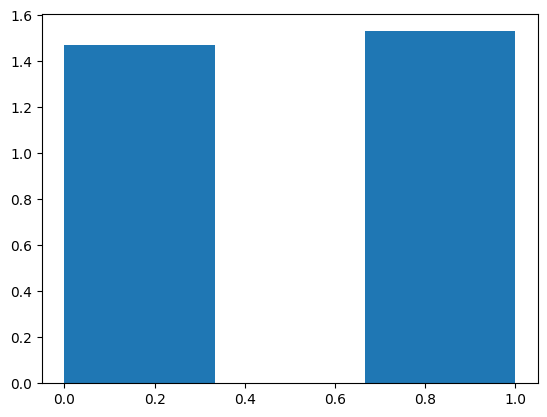

In [34]:
density, bins, patches = plt.hist(final_Do_counts,bins= 3,density=True)

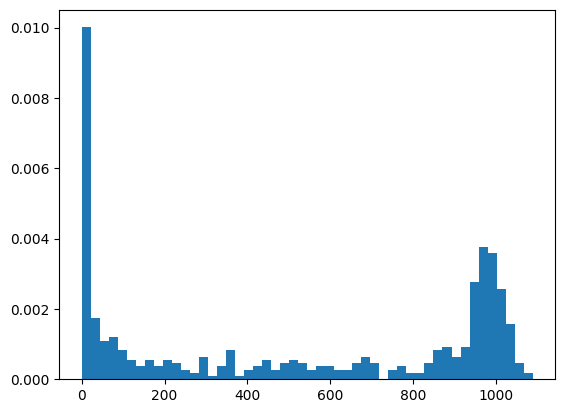

In [35]:
density, bins, patches = plt.hist(final_lacY_counts, bins=50, density=True)

In [21]:
from collections import defaultdict
state_wise_end_counts = defaultdict(list)

for i in range(1,n_trajectories+1):
    smod.GetTrajectoryData(i)
    final_Do_count = smod.data_stochsim.species[-1, smod.data_stochsim.species_labels.index('Do')]
    state_wise_end_counts[final_Do_count].append(smod.data_stochsim.species[-1, smod.data_stochsim.species_labels.index('LacY')])

In [29]:
for state in state_wise_end_counts.keys():
    x = state_wise_end_counts[state]
    print(f'{sum(x)/len(x)} is the mean LacY count of state {state}' )

159.61632653061224 is the mean LacY count of state 0
863.8392156862745 is the mean LacY count of state 1
